In [3]:
# Standard library
import os
from pathlib import Path  # Object-oriented filesystem paths

# Data handling packages
import numpy as np
import numpy.random as npr
import pandas as pd

# pynwb reads the Neuropixels session file (NWB format)
import pynwb

# Progress bar utility
from tqdm import tqdm  # Displays a smart progress bar during loops

# Preprocessing
from sklearn.preprocessing import StandardScaler  # Standardizes features (zero mean, unit variance)

# Machine learning
from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

# Plotting libraries
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

# Plot/display settings
sns.set_context('talk')                      # readable on a projector
pd.set_option('display.max_columns', None)    # show all columns when printing DataFrames

# Inline plotting for Jupyter Notebooks
%matplotlib inline

In [4]:
#got rid of root = path line
#and d in root.iterdir()
import glob

# the capsule stores each session as a .nwb.zarr folder; glob finds it so we
# never hardcode the parent directory
data_root = '/root/capsule/data/dynamicrouting_datacube'

example_session_ids = [
    # "759434_2025-02-04", #"713655_2024-08-09", "743199_2024-12-05",
    # # "712815_2024-05-22", "742903_2024-10-23", "664851_2023-11-16",
    # # "741137_2024-10-10", "662892_2023-08-24", "714748_2024-06-24",
    "667252_2023-09-28" #"715710_2024-07-16", "708016_2024-04-29",
]

session_id = example_session_ids[0]

match_list = glob.glob('%s/*/%s.nwb.zarr' % (data_root, session_id))
assert len(match_list) == 1, \
    'expected exactly one match for session %s, found %d' % (session_id, len(match_list))
nwb_path = match_list[0]
print('loading session from: %s' % nwb_path)

session = pynwb.read_nwb(nwb_path)
print('loaded session %s' % session_id)

loading session from: /root/capsule/data/dynamicrouting_datacube/ecephys_667252_2023-09-28_15-00-38_nwb_2026-08-04_15-21-37/667252_2023-09-28.nwb.zarr


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (439878, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (439866, 500) float32 read-only>
  warnings.warn(


loaded session 667252_2023-09-28


In [5]:
session = pynwb.read_nwb(nwb_path)
#session

In [4]:
trials = session.trials.to_dataframe()
print('this session has %d trials' % len(trials))
#trials.head()

this session has 486 trials


In [5]:
df = session.units.to_dataframe()
units_table = df.sort_values(by=['firing_rate', 'snr'], ascending=False) #also sorted by signal to noise ratio (snr)
#units_table.head()

In [6]:
#ALLEN SWDB CODE #
# QC thresholds
MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better

good_units = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO)
]
print('%d of %d units passed quality control' % (len(good_units), len(units_table)))



brain_area = 'MOs'
this_structure_units_table = good_units[good_units.structure == 'MOs']
print('%d good units in MOs (secondary motor cortex)' % len(this_structure_units_table))

524 of 1181 units passed quality control
190 good units in MOs (secondary motor cortex)


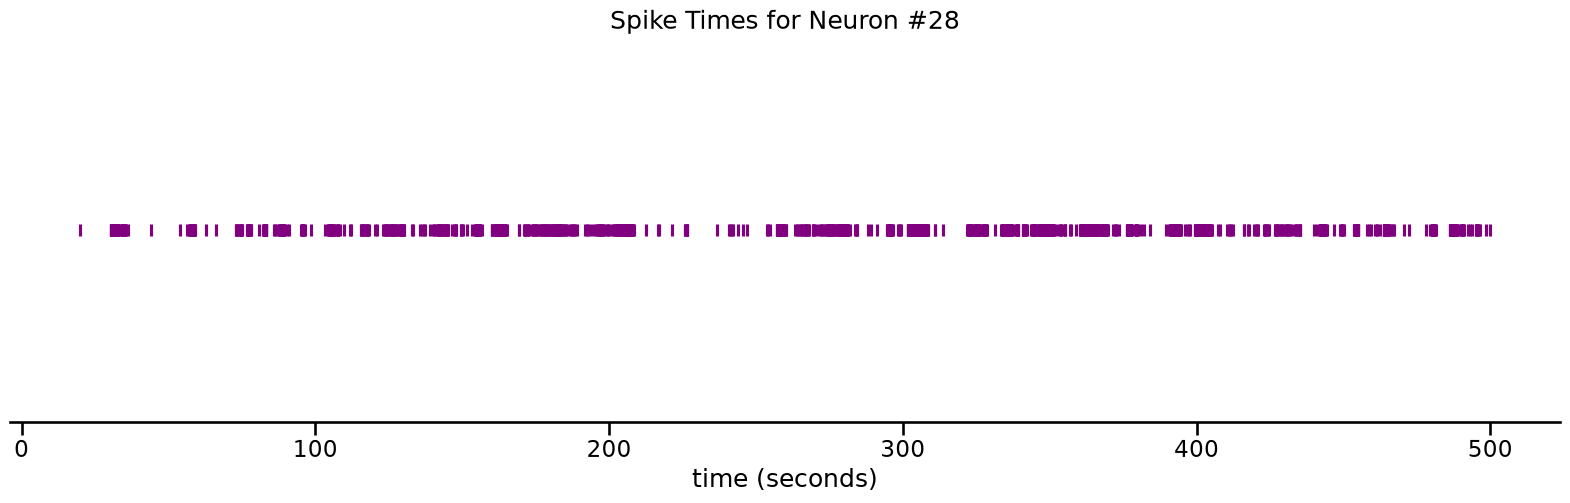

In [7]:
neuron_index = 916          
pre_window = 0.0         #in sec set to None to start at the beginning
end_time = 500.0           #"" end


#get spike times for that neuron
spike_times = units_table.loc[neuron_index]['spike_times']
neuron_id = units_table.loc[neuron_index]['cluster_id']

#restrict to a time window
if pre_window is not None:
    spike_times = spike_times[spike_times >= pre_window]
if end_time is not None:
    spike_times = spike_times[spike_times <= end_time]


fig, ax = plt.subplots(figsize=(20, 5))
ax.scatter(spike_times, np.ones_like(spike_times), marker='|', color='purple')
ax.set_xlabel('time (seconds)')
ax.set_yticks([])                        
for spine_position in ['top', 'right', 'left']:
    ax.spines[spine_position].set_visible(False)
ax.set_title('Spike Times for Neuron #%d' % neuron_id)
plt.show()

In [8]:
spike_times = this_structure_units_table.spike_times.values[neuron_id]

#firing rate value per trial 
trial_firing_rates = []

for _, trial in trials.iterrows():
    duration = trial.stop_time - trial.start_time
    spikes_in_trial = spike_times[(spike_times >= trial.start_time) & (spike_times < trial.stop_time)]
    rate = len(spikes_in_trial) / duration
    trial_firing_rates.append(rate)

trials["firing_rate"] = trial_firing_rates


In [9]:

trials["firing_rate_hit"] = np.where(trials["is_hit"], trials["firing_rate"], np.nan)
trials["firing_rate_fa"] = np.where(trials["is_false_alarm"], trials["firing_rate"], np.nan)

In [10]:
hit_trials = trials[trials.is_hit]
fa_trials = trials[trials.is_false_alarm]

In [ ]:
spike_times = this_structure_units_table.spike_times.values[neuron_id]

print('neuron %d has %d spikes' % (neuron_id, len(spike_times)))

def align_spikes_to_trials(spike_times, trial_subset, pre_window, post_window):
    triggered_spike_times = []
    triggered_trial_index = []

    stim_times = trial_subset["stim_start_time"].values

    for i, stim_time in enumerate(stim_times):
        mask = ((spike_times >= stim_time - pre_window) &
                (spike_times < stim_time + post_window))
        trial_spikes = spike_times[mask] - stim_time
        triggered_spike_times.append(trial_spikes)
        triggered_trial_index.append(np.ones(len(trial_spikes)) * i)

    triggered_spike_times = np.concatenate(triggered_spike_times)
    triggered_trial_index = np.concatenate(triggered_trial_index)

    return triggered_spike_times, triggered_trial_index


vis_trials = trials[trials.is_vis_stim]
aud_trials = trials[trials.is_aud_stim]

vis_spike_times, vis_trial_index = align_spikes_to_trials(spike_times, vis_trials, pre_window, post_window)
aud_spike_times, aud_trial_index = align_spikes_to_trials(spike_times, aud_trials, pre_window, post_window)

print('collected spikes %d visual trials' % len(vis_trials))
print('collected spikes %d auditory trials' % len(aud_trials))


vis_color = 'turquoise'
aud_color = 'mediumpurple'


vis_count_array, _ = np.histogram(vis_spike_times, bins=bins)
vis_rate_array = vis_count_array / len(vis_trials) / bin_size

aud_count_array, _ = np.histogram(aud_spike_times, bins=bins)
aud_rate_array = aud_count_array / len(aud_trials) / bin_size


fig, (ax_raster, ax_trace) = plt.subplots(
    nrows=2, figsize=(12, 9), sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)

ax_raster.scatter(vis_spike_times, vis_trial_index, s=2, c=vis_color, label='Visual')
ax_raster.axvline(0, c='k', lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, visual trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)

ax_trace.plot(bin_centers, vis_rate_array, c=vis_color, lw=2, label='Visual')
ax_trace.axvline(0, c='k', lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)

for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()


fig, (ax_raster, ax_trace) = plt.subplots(
    nrows=2, figsize=(12, 9), sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)

ax_raster.scatter(aud_spike_times, aud_trial_index, s=2, c=aud_color, label='Auditory')
ax_raster.axvline(0, c='k', lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, auditory trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)

ax_trace.plot(bin_centers, aud_rate_array, c=aud_color, lw=2, label='Auditory')
ax_trace.axvline(0, c='k', lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)

for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()


fig, (ax_raster, ax_trace) = plt.subplots(
    nrows=2, figsize=(12, 9), sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)

ax_raster.scatter(vis_spike_times, vis_trial_index, s=2, c=vis_color, label='Visual')
ax_raster.scatter(aud_spike_times, aud_trial_index + len(vis_trials), s=2, c=aud_color, label='Auditory')
# ax.scatter(spike_times, np.ones_like(spike_times), 

ax_raster.axvline(0, c='k', lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, visual vs auditory' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)

ax_trace.plot(bin_centers, vis_rate_array, c=vis_color, lw=2, label='Visual')
ax_trace.plot(bin_centers, aud_rate_array, c=aud_color, lw=2, label='Auditory')
ax_trace.axvline(0, c='k', lw=1)

ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)

for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

neuron 28 has 87784 spikes
61 trials for Visual (reward time)
65 trials for Auditory (reward time)


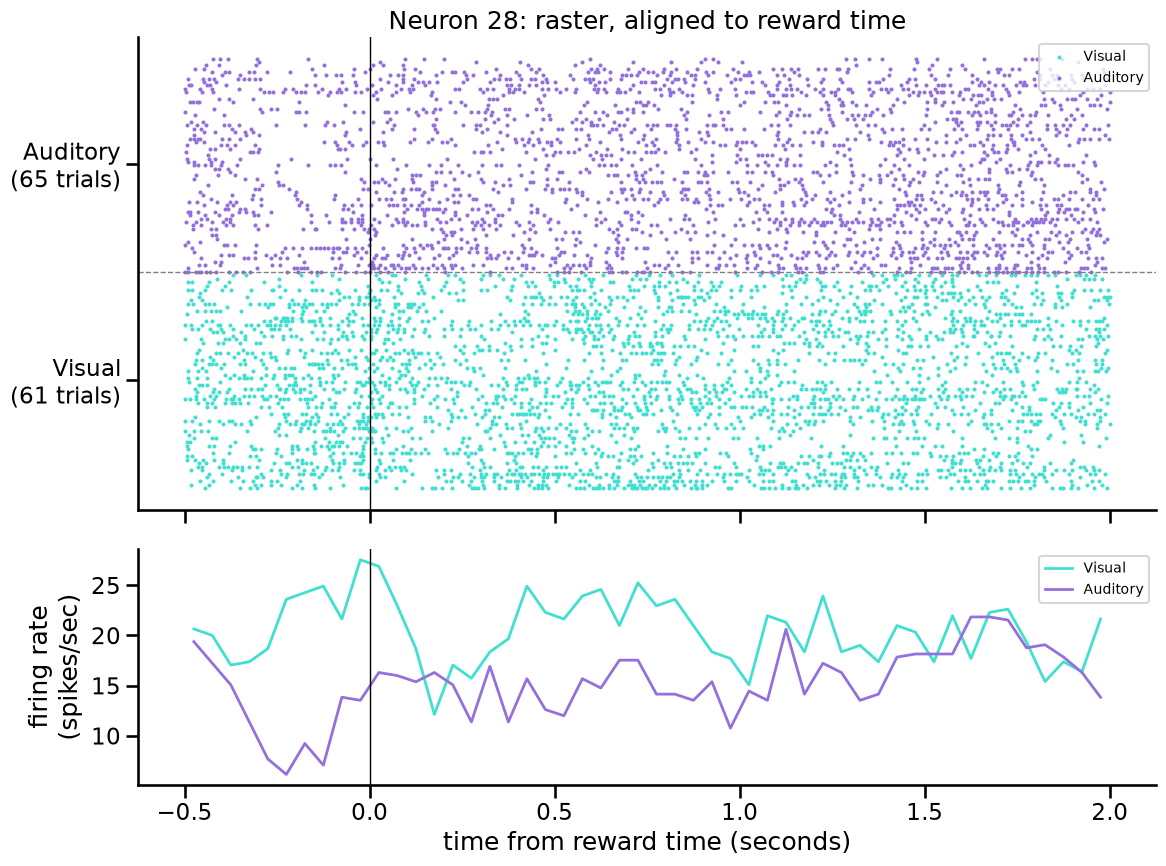

83 trials for Visual (first lick)
86 trials for Auditory (first lick)


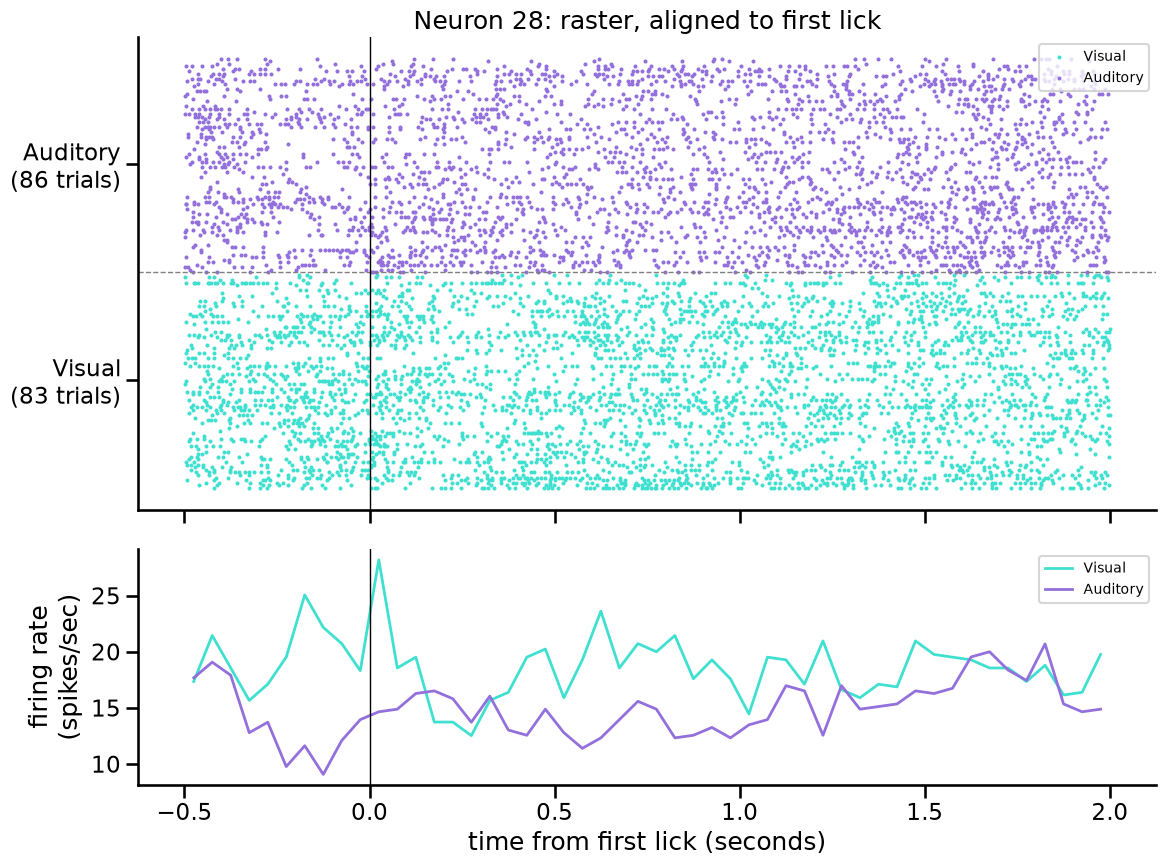

209 trials for Visual (quiescent start)
215 trials for Auditory (quiescent start)


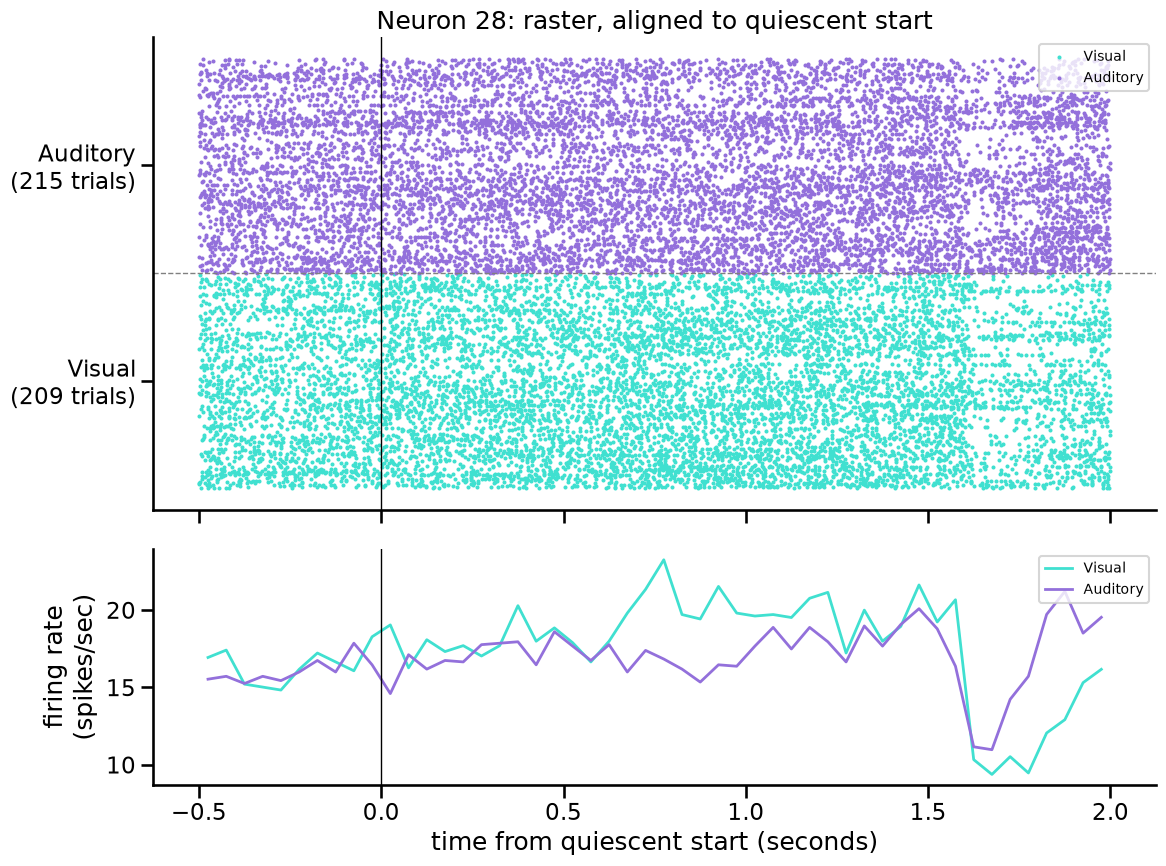

In [ ]:
# # neuron_index = 100
# # spike_times = this_structure_units_table.spike_times.values[neuron_id]

# print('neuron %d has %d spikes' % (neuron_id, len(spike_times)))

# pre_window = 0.5
# post_window = 2.0
# bin_size = 0.05
# bins = np.arange(-pre_window, post_window + bin_size, bin_size)
# bin_centers = bins[:-1] + bin_size / 2

# lane_height = 100

# def align_spikes_to_events(spike_times, event_times, pre_window, post_window):
#     triggered_spike_times = []
#     triggered_trial_index = []

#     for i, event_time in enumerate(event_times):
#         mask = ((spike_times >= event_time - pre_window) &
#                 (spike_times < event_time + post_window))
#         trial_spikes = spike_times[mask] - event_time
#         triggered_spike_times.append(trial_spikes)
#         triggered_trial_index.append(np.ones(len(trial_spikes)) * i)

#     triggered_spike_times = np.concatenate(triggered_spike_times)
#     triggered_trial_index = np.concatenate(triggered_trial_index)

#     return triggered_spike_times, triggered_trial_index



# def plot_event_aligned_by_group(spike_times, trial_subset, event_column, event_label, neuron_id, group_defs):
#     fig, (ax_raster, ax_trace) = plt.subplots(
#         nrows=2, figsize=(12, 9), sharex=True,
#         gridspec_kw={'height_ratios': [2, 1]}
#     )

#     yticks = []
#     yticklabels = []

#     for lane_number, (group_label, (mask_column, color)) in enumerate(group_defs.items()):
#         #build the mask FROM trial_subset itself, not from the outer trials table
#         group_trials = trial_subset[trial_subset[mask_column]]
#         event_times = group_trials[event_column].dropna().values

#         print('%d trials for %s (%s)' % (len(event_times), group_label, event_label))

#         if len(event_times) == 0:
#             continue

#         triggered_spike_times, triggered_trial_index = align_spikes_to_events(
#             spike_times, event_times, pre_window, post_window
#         )

#         count_array, _ = np.histogram(triggered_spike_times, bins=bins)
#         rate_array = count_array / len(event_times) / bin_size

#         trial_index_scaled = (triggered_trial_index / len(event_times)) * lane_height + (lane_number * lane_height)

#         ax_raster.scatter(triggered_spike_times, trial_index_scaled, s=2, c=color, label=group_label)
#         ax_trace.plot(bin_centers, rate_array, c=color, lw=2, label=group_label)

#         yticks.append(lane_number * lane_height + lane_height / 2)
#         yticklabels.append('%s\n(%d trials)' % (group_label, len(event_times)))

#         if lane_number < len(group_defs) - 1:
#             ax_raster.axhline((lane_number + 1) * lane_height, c='gray', lw=1, ls='--')

#     ax_raster.axvline(0, c='k', lw=1)
#     ax_raster.set_yticks(yticks)
#     ax_raster.set_yticklabels(yticklabels)
#     ax_raster.set_title('Neuron %d: raster, aligned to %s' % (neuron_id, event_label))
#     ax_raster.legend(loc='upper right', fontsize=10)

#     ax_trace.axvline(0, c='k', lw=1)
#     ax_trace.set_xlabel('time from %s (seconds)' % event_label)
#     ax_trace.set_ylabel('firing rate\n(spikes/sec)')
#     ax_trace.legend(loc='upper right', fontsize=10)

#     for single_ax in [ax_raster, ax_trace]:
#         sns.despine(ax=single_ax)
#     fig.tight_layout()
#     plt.show()



# group_defs = {
#     'Visual':   ('is_vis_stim', 'turquoise'),
#     'Auditory': ('is_aud_stim', 'mediumpurple'),
#     #'Catch':    ('is_catch',    'salmon'),
# }

# reward_trials = trials[trials["reward_time"].notna()]
# plot_event_aligned_by_group(spike_times, reward_trials, "reward_time", "reward time", neuron_id, group_defs)

# lick_trials = trials[trials["is_response"] & trials["response_time"].notna()]
# plot_event_aligned_by_group(spike_times, lick_trials, "response_time", "first lick", neuron_id, group_defs)

# plot_event_aligned_by_group(spike_times, trials, "quiescent_start_time", "quiescent start", neuron_id, group_defs)

In [ ]:
lane_height = 100

#reusable function, works for any event time (reward, lick, quiescent start, etc)
def align_spikes_to_events(spike_times, event_times, pre_window, post_window):
    triggered_spike_times = []
    triggered_trial_index = []

    for i, event_time in enumerate(event_times):
        mask = ((spike_times >= event_time - pre_window) &
                (spike_times < event_time + post_window))
        trial_spikes = spike_times[mask] - event_time
        triggered_spike_times.append(trial_spikes)
        triggered_trial_index.append(np.ones(len(trial_spikes)) * i)

    triggered_spike_times = np.concatenate(triggered_spike_times)
    triggered_trial_index = np.concatenate(triggered_trial_index)

    return triggered_spike_times, triggered_trial_index


#now takes pre_window/post_window/bin_size as arguments for window size
def plot_event_aligned_by_group(spike_times, trial_subset, event_column, event_label, neuron_id,
                                 group_defs, pre_window, post_window, bin_size):

    bins = np.arange(-pre_window, post_window + bin_size, bin_size)
    bin_centers = bins[:-1] + bin_size / 2

    fig, (ax_raster, ax_trace) = plt.subplots(
        nrows=2, figsize=(12, 9), sharex=True,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    yticks = []
    yticklabels = []

    for lane_number, (group_label, (group_mask, color)) in enumerate(group_defs.items()):
        group_trials = trial_subset[trial_subset[group_mask]] if isinstance(group_mask, str) else trial_subset[group_mask]
        event_times = group_trials[event_column].dropna().values

        print('%d trials for %s (%s)' % (len(event_times), group_label, event_label))

        if len(event_times) == 0:
            continue   #skip empty groups so we don't divide by zero

        triggered_spike_times, triggered_trial_index = align_spikes_to_events(
            spike_times, event_times, pre_window, post_window
        )

        count_array, _ = np.histogram(triggered_spike_times, bins=bins)
        rate_array = count_array / len(event_times) / bin_size

        #scale to its own lane
        trial_index_scaled = (triggered_trial_index / len(event_times)) * lane_height + (lane_number * lane_height)

        ax_raster.scatter(triggered_spike_times, trial_index_scaled, s=2, c=color, label=group_label)
        ax_trace.plot(bin_centers, rate_array, c=color, lw=2, label=group_label)

        yticks.append(lane_number * lane_height + lane_height / 2)
        yticklabels.append('%s\n(%d trials)' % (group_label, len(event_times)))

        if lane_number < len(group_defs) - 1:
            ax_raster.axhline((lane_number + 1) * lane_height, c='gray', lw=1, ls='--')

    ax_raster.axvline(0, c='k', lw=1)
    ax_raster.set_yticks(yticks)
    ax_raster.set_yticklabels(yticklabels)
    ax_raster.set_title('Neuron %d: raster, aligned to %s' % (neuron_id, event_label))
    ax_raster.legend(loc='upper right', fontsize=10)

    ax_trace.axvline(0, c='k', lw=1)
    ax_trace.set_xlabel('time from %s (seconds)' % event_label)
    ax_trace.set_ylabel('firing rate\n(spikes/sec)')
    ax_trace.legend(loc='upper right', fontsize=10)

    for single_ax in [ax_raster, ax_trace]:
        sns.despine(ax=single_ax)
    fig.tight_layout()
    plt.show()


#group defs use COLUMN NAMES (strings), looked up fresh from whichever trial_subset gets passed in
group_defs = {
    'Visual':   ('is_vis_stim', 'turquoise'),
    'Auditory': ('is_aud_stim', 'mediumpurple'),
    #'Catch':    ('is_catch',    'salmon'),
}

#reward and quiescent plots keep the original ±0.5/2.0 sec window
reward_trials = trials[trials["reward_time"].notna()]
plot_event_aligned_by_group(spike_times, reward_trials, "reward_time", "reward time", neuron_id,
                             group_defs, pre_window=0.5, post_window=2.0, bin_size=0.05)

plot_event_aligned_by_group(spike_times, trials, "quiescent_start_time", "quiescent start", neuron_id,
                             group_defs, pre_window=0.5, post_window=2.0, bin_size=0.05)

#lick plot now uses seconds window
lick_trials = trials[trials["is_response"] & trials["response_time"].notna()]
plot_event_aligned_by_group(spike_times, lick_trials, "response_time", "first lick", neuron_id,
                             group_defs, pre_window=-0.5, post_window=1.5, bin_size=0.1)

In [1]:
# ==== imports & settings ====
import os
import glob
import numpy as np
import pandas as pd
import pynwb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_context('talk')
pd.set_option('display.max_columns', None)

C_TEAL   = "#48A69C"
C_ORANGE = "#E78C3B"
C_PURPLE = "#7D57C1"
C_GREY   = "#333333"

# new hit/false-alarm colors
C_HIT = "#6464FF"   # blue
C_FA  = "#E78C3B"   # orange

def lighten_color(hex_color, amount=0.5):
    rgb = mcolors.to_rgb(hex_color)
    return tuple(rgb[i] + (1 - rgb[i]) * amount for i in range(3))


# ==== neuron table + mouse -> session lookup ====
target_neurons = pd.DataFrame([
    {"id": 105,  "structure": "MOs", "cluster_id": 116, "block": "auditory", "mouse_id": 708016},
    {"id": 1593, "structure": "MOs", "cluster_id": 474, "block": "auditory", "mouse_id": 664851},
    {"id": 106,  "structure": "MOs", "cluster_id": 113, "block": "auditory", "mouse_id": 664851},
    {"id": 962,  "structure": "MOs", "cluster_id": 78,  "block": "auditory", "mouse_id": 667252},
    {"id": 74,   "structure": "MOs", "cluster_id": 78,  "block": "auditory", "mouse_id": 667252},
    {"id": 916,  "structure": "MOs", "cluster_id": 28,  "block": "auditory", "mouse_id": 667252},
    {"id": 1768, "structure": "MOs", "cluster_id": 481, "block": "visual",   "mouse_id": 715710},
    {"id": 2124, "structure": "MOs", "cluster_id": 857, "block": "visual",   "mouse_id": 715710},
    {"id": 23,   "structure": "MOs", "cluster_id": 23,  "block": "visual",   "mouse_id": 667252},
    {"id": 94,   "structure": "MOs", "cluster_id": 105, "block": "visual",   "mouse_id": 708016},
    {"id": 1631, "structure": "MOs", "cluster_id": 39,  "block": "visual",   "mouse_id": 743199},  # table said 723199 -- confirm
    {"id": 2777, "structure": "MOp", "cluster_id": 565, "block": "auditory", "mouse_id": 742903},
    {"id": 2918, "structure": "MOp", "cluster_id": 711, "block": "auditory", "mouse_id": 742903},
    {"id": 841,  "structure": "MOp", "cluster_id": 476, "block": "auditory", "mouse_id": 708016},
    {"id": 2693, "structure": "MOp", "cluster_id": 684, "block": "visual",   "mouse_id": 742903},
    {"id": 586,  "structure": "MOp", "cluster_id": 213, "block": "visual",   "mouse_id": 708016},
    {"id": 325,  "structure": "MOp", "cluster_id": 188, "block": "visual",   "mouse_id": 667252},
])

# ---- only keep neurons 105 and 23 ----
target_neurons = target_neurons[target_neurons["id"].isin([105, 23])].reset_index(drop=True)

mouse_to_session = {
    708016: "708016_2024-04-29",
    664851: "664851_2023-11-16",
    667252: "667252_2023-09-28",
    715710: "715710_2024-07-16",
    742903: "742903_2024-10-23",
    743199: "743199_2024-12-05",
}
target_neurons["session_id"] = target_neurons["mouse_id"].map(mouse_to_session)

data_root = '/root/capsule/data/dynamicrouting_datacube'
output_root = '/root/capsule/results/psth_plots'   # change this to wherever you want the folders to land

MAX_ISI_VIOLATIONS_RATIO = 0.5
MAX_AMPLITUDE_CUTOFF = 0.1
MIN_PRESENCE_RATIO = 0.95

STIM_PRE = 1.5     # partner's spec: 1.5s quiescent
STIM_POST = 1.0    # partner's spec: 1.0s stim + response
BIN_SIZE = 0.05


# ==== helper functions ====

def load_session(session_id):
    match_list = glob.glob('%s/*/%s.nwb.zarr' % (data_root, session_id))
    if len(match_list) != 1:
        print('skipping %s -- expected 1 match, found %d' % (session_id, len(match_list)))
        return None, None
    session = pynwb.read_nwb(match_list[0])
    trials = session.trials.to_dataframe()
    units_table = session.units.to_dataframe()
    good_units = units_table[
        (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
        (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
        (units_table.presence_ratio > MIN_PRESENCE_RATIO)
    ]
    return trials, good_units


def align_spikes_to_events(spike_times, event_times, pre_window, post_window):
    triggered_spike_times = []
    triggered_trial_index = []
    for i, event_time in enumerate(event_times):
        mask = (spike_times >= event_time - pre_window) & (spike_times < event_time + post_window)
        trial_spikes = spike_times[mask] - event_time
        triggered_spike_times.append(trial_spikes)
        triggered_trial_index.append(np.ones(len(trial_spikes)) * i)
    return np.concatenate(triggered_spike_times), np.concatenate(triggered_trial_index)


def compute_lick_window(trials):
    """median stim->lick and lick->response-end durations, used to size the lick-aligned window"""
    responded = trials[trials["is_response"] & trials["response_time"].notna()]
    stim_to_lick = (responded["response_time"] - responded["stim_start_time"]).median()
    lick_to_resp_end = (responded["response_window_stop_time"] - responded["response_time"]).median()
    return stim_to_lick, lick_to_resp_end


def plot_pair(spike_times, group_a, label_a, color_a, group_b, label_b, color_b,
              align_column, pre_window, post_window, bin_size, title,
              orange_marker_time=None, orange_marker_label=None, save_path=None):
    """combined two-lane raster + overlaid trace for two trial groups, optional orange marker line"""
    bins = np.arange(-pre_window, post_window + bin_size, bin_size)
    bin_centers = bins[:-1] + bin_size / 2
    lane_height = 100

    a_times = group_a[align_column].dropna().values
    b_times = group_b[align_column].dropna().values
    if len(a_times) == 0 or len(b_times) == 0:
        print('skipping "%s" -- one group has 0 trials (%s: %d, %s: %d)' %
              (title, label_a, len(a_times), label_b, len(b_times)))
        return

    a_spikes, a_index = align_spikes_to_events(spike_times, a_times, pre_window, post_window)
    b_spikes, b_index = align_spikes_to_events(spike_times, b_times, pre_window, post_window)

    a_rate, _ = np.histogram(a_spikes, bins=bins)
    a_rate = a_rate / len(a_times) / bin_size
    b_rate, _ = np.histogram(b_spikes, bins=bins)
    b_rate = b_rate / len(b_times) / bin_size

    a_index_scaled = (a_index / len(a_times)) * lane_height
    b_index_scaled = (b_index / len(b_times)) * lane_height + lane_height

    fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    ax_raster.scatter(a_spikes, a_index_scaled, s=2, c=color_a, label=label_a)
    ax_raster.scatter(b_spikes, b_index_scaled, s=2, c=color_b, label=label_b)
    ax_raster.axhline(lane_height, c=C_GREY, lw=1, ls='--')
    ax_raster.axvline(0, c=C_GREY, lw=1)
    if orange_marker_time is not None:
        ax_raster.axvline(orange_marker_time, c=C_GREY, lw=1.5, ls='--', label=orange_marker_label)
    ax_raster.set_yticks([lane_height / 2, lane_height + lane_height / 2])
    ax_raster.set_yticklabels(['%s\n(%d trials)' % (label_a, len(a_times)), '%s\n(%d trials)' % (label_b, len(b_times))])
    ax_raster.set_title(title)
    ax_raster.legend(loc='upper right', fontsize=9)

    ax_trace.plot(bin_centers, a_rate, c=color_a, lw=2, label=label_a)
    ax_trace.plot(bin_centers, b_rate, c=color_b, lw=2, label=label_b)
    ax_trace.axvline(0, c=C_GREY, lw=1)
    if orange_marker_time is not None:
        ax_trace.axvline(orange_marker_time, c=C_GREY, lw=1.5, ls='--', label=orange_marker_label)
    ax_trace.set_xlabel('time (seconds)')
    ax_trace.set_ylabel('firing rate\n(spikes/sec)')
    ax_trace.legend(loc='upper right', fontsize=9)

    for single_ax in [ax_raster, ax_trace]:
        sns.despine(ax=single_ax)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150)
        plt.close(fig)
        print('saved: %s' % save_path)
    else:
        plt.show()


# ==== main loop: neurons 105 and 23 only, stim-aligned hit vs FA plots only ====
session_cache = {}   # avoid reloading the same session multiple times

for _, row in target_neurons.iterrows():
    session_id = row.session_id
    if session_id is None or pd.isna(session_id):
        print('no known session for mouse %s (id %d) -- skipping' % (row.mouse_id, row.id))
        continue

    if session_id not in session_cache:
        session_cache[session_id] = load_session(session_id)
    trials, good_units = session_cache[session_id]
    if good_units is None:
        continue

    structure_units = good_units[good_units.structure == row.structure]
    match = structure_units[structure_units.cluster_id == row.cluster_id]
    if len(match) == 0:
        print('no match for id %d (cluster_id %d, %s) in session %s' % (row.id, row.cluster_id, row.structure, session_id))
        continue

    neuron_id = row.cluster_id
    spike_times = match.iloc[0].spike_times

    # ---- output folder: one subfolder per mouse ID ----
    mouse_folder = os.path.join(output_root, str(row.mouse_id))
    os.makedirs(mouse_folder, exist_ok=True)
    file_prefix = 'neuron%d_%s' % (neuron_id, row.structure)

    vis_trials = trials[trials.is_vis_stim]
    aud_trials = trials[trials.is_aud_stim]
    vis_hit = vis_trials[vis_trials.is_hit]
    vis_fa = vis_trials[vis_trials.is_false_alarm]
    aud_hit = aud_trials[aud_trials.is_hit]
    aud_fa = aud_trials[aud_trials.is_false_alarm]

    stim_to_lick, lick_to_resp_end = compute_lick_window(trials)
    print('neuron %d (mouse %s): median stim->lick = %.2fs, lick->response end = %.2fs' %
          (neuron_id, row.mouse_id, stim_to_lick, lick_to_resp_end))

    # ---- STIM-ALIGNED hit vs false alarm (-1.5s to +1.0s), orange line = median lick time ----
    plot_pair(spike_times, vis_hit, 'Hit', C_HIT, vis_fa, 'False Alarm', C_FA,
              'stim_start_time', STIM_PRE, STIM_POST, BIN_SIZE,
              'Neuron %d: visual, hit vs false alarm (stim-aligned)' % neuron_id,
              orange_marker_time=stim_to_lick, orange_marker_label='median lick time',
              save_path=os.path.join(mouse_folder, '%s_visual_hit_vs_fa_stimaligned.png' % file_prefix))

    plot_pair(spike_times, aud_hit, 'Hit', C_HIT, aud_fa, 'False Alarm', C_FA,
              'stim_start_time', STIM_PRE, STIM_POST, BIN_SIZE,
              'Neuron %d: auditory, hit vs false alarm (stim-aligned)' % neuron_id,
              orange_marker_time=stim_to_lick, orange_marker_label='median lick time',
              save_path=os.path.join(mouse_folder, '%s_auditory_hit_vs_fa_stimaligned.png' % file_prefix))

print('done -- check %s for saved plots, organized by mouse ID folder' % output_root)


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (435944, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (435963, 500) float32 read-only>
  warnings.warn(


neuron 116 (mouse 708016): median stim->lick = 0.43s, lick->response end = 0.56s
saved: /root/capsule/results/psth_plots/708016/neuron116_MOs_visual_hit_vs_fa_stimaligned.png
saved: /root/capsule/results/psth_plots/708016/neuron116_MOs_auditory_hit_vs_fa_stimaligned.png


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (439878, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (439866, 500) float32 read-only>
  warnings.warn(


neuron 23 (mouse 667252): median stim->lick = 0.44s, lick->response end = 0.55s
saved: /root/capsule/results/psth_plots/667252/neuron23_MOs_visual_hit_vs_fa_stimaligned.png
saved: /root/capsule/results/psth_plots/667252/neuron23_MOs_auditory_hit_vs_fa_stimaligned.png
done -- check /root/capsule/results/psth_plots for saved plots, organized by mouse ID folder


In [3]:
# ==== imports & settings ====
import os
import glob
import numpy as np
import pandas as pd
import pynwb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_context('talk')
pd.set_option('display.max_columns', None)

C_TEAL   = "#48A69C"
C_ORANGE = "#E78C3B"
C_PURPLE = "#7D57C1"
C_GREY   = "#333333"

# new hit/false-alarm colors
C_HIT = "#6464FF"   # blue
C_FA  = "#E78C3B"   # orange

def lighten_color(hex_color, amount=0.5):
    rgb = mcolors.to_rgb(hex_color)
    return tuple(rgb[i] + (1 - rgb[i]) * amount for i in range(3))


# ==== neuron table + mouse -> session lookup ====
target_neurons = pd.DataFrame([
    {"id": 105,  "structure": "MOs", "cluster_id": 116, "block": "auditory", "mouse_id": 708016},
    {"id": 1593, "structure": "MOs", "cluster_id": 474, "block": "auditory", "mouse_id": 664851},
    {"id": 106,  "structure": "MOs", "cluster_id": 113, "block": "auditory", "mouse_id": 664851},
    {"id": 962,  "structure": "MOs", "cluster_id": 78,  "block": "auditory", "mouse_id": 667252},
    {"id": 74,   "structure": "MOs", "cluster_id": 78,  "block": "auditory", "mouse_id": 667252},
    {"id": 916,  "structure": "MOs", "cluster_id": 28,  "block": "auditory", "mouse_id": 667252},
    {"id": 1768, "structure": "MOs", "cluster_id": 481, "block": "visual",   "mouse_id": 715710},
    {"id": 2124, "structure": "MOs", "cluster_id": 857, "block": "visual",   "mouse_id": 715710},
    {"id": 23,   "structure": "MOs", "cluster_id": 23,  "block": "visual",   "mouse_id": 667252},
    {"id": 94,   "structure": "MOs", "cluster_id": 105, "block": "visual",   "mouse_id": 708016},
    {"id": 1631, "structure": "MOs", "cluster_id": 39,  "block": "visual",   "mouse_id": 743199},  # table said 723199 -- confirm
    {"id": 2777, "structure": "MOp", "cluster_id": 565, "block": "auditory", "mouse_id": 742903},
    {"id": 2918, "structure": "MOp", "cluster_id": 711, "block": "auditory", "mouse_id": 742903},
    {"id": 841,  "structure": "MOp", "cluster_id": 476, "block": "auditory", "mouse_id": 708016},
    {"id": 2693, "structure": "MOp", "cluster_id": 684, "block": "visual",   "mouse_id": 742903},
    {"id": 586,  "structure": "MOp", "cluster_id": 213, "block": "visual",   "mouse_id": 708016},
    {"id": 325,  "structure": "MOp", "cluster_id": 188, "block": "visual",   "mouse_id": 667252},
])

# ---- only keep neurons 105 and 23 ----
target_neurons = target_neurons[target_neurons["id"].isin([105, 23])].reset_index(drop=True)

mouse_to_session = {
    708016: "708016_2024-04-29",
    664851: "664851_2023-11-16",
    667252: "667252_2023-09-28",
    715710: "715710_2024-07-16",
    742903: "742903_2024-10-23",
    743199: "743199_2024-12-05",
}
target_neurons["session_id"] = target_neurons["mouse_id"].map(mouse_to_session)

data_root = '/root/capsule/data/dynamicrouting_datacube'
output_root = '/root/capsule/results/psth_plots'   # change this to wherever you want the folders to land

MAX_ISI_VIOLATIONS_RATIO = 0.5
MAX_AMPLITUDE_CUTOFF = 0.1
MIN_PRESENCE_RATIO = 0.95

STIM_PRE = 1.5     # partner's spec: 1.5s quiescent
STIM_POST = 1.0    # partner's spec: 1.0s stim + response
BIN_SIZE = 0.05


# ==== helper functions ====

def load_session(session_id):
    match_list = glob.glob('%s/*/%s.nwb.zarr' % (data_root, session_id))
    if len(match_list) != 1:
        print('skipping %s -- expected 1 match, found %d' % (session_id, len(match_list)))
        return None, None
    session = pynwb.read_nwb(match_list[0])
    trials = session.trials.to_dataframe()
    units_table = session.units.to_dataframe()
    good_units = units_table[
        (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
        (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
        (units_table.presence_ratio > MIN_PRESENCE_RATIO)
    ]
    return trials, good_units


def align_spikes_to_events(spike_times, event_times, pre_window, post_window):
    triggered_spike_times = []
    triggered_trial_index = []
    for i, event_time in enumerate(event_times):
        mask = (spike_times >= event_time - pre_window) & (spike_times < event_time + post_window)
        trial_spikes = spike_times[mask] - event_time
        triggered_spike_times.append(trial_spikes)
        triggered_trial_index.append(np.ones(len(trial_spikes)) * i)
    return np.concatenate(triggered_spike_times), np.concatenate(triggered_trial_index)


def compute_lick_window(trials):
    """median stim->lick and lick->response-end durations, used to size the lick-aligned window"""
    responded = trials[trials["is_response"] & trials["response_time"].notna()]
    stim_to_lick = (responded["response_time"] - responded["stim_start_time"]).median()
    lick_to_resp_end = (responded["response_window_stop_time"] - responded["response_time"]).median()
    return stim_to_lick, lick_to_resp_end


def plot_pair(spike_times, group_a, label_a, color_a, group_b, label_b, color_b,
              align_column, pre_window, post_window, bin_size, title,
              orange_marker_time=None, orange_marker_label=None, save_path=None):
    """combined two-lane raster + overlaid trace for two trial groups, optional orange marker line"""
    bins = np.arange(-pre_window, post_window + bin_size, bin_size)
    bin_centers = bins[:-1] + bin_size / 2
    lane_height = 100

    a_times = group_a[align_column].dropna().values
    b_times = group_b[align_column].dropna().values
    if len(a_times) == 0 or len(b_times) == 0:
        print('skipping "%s" -- one group has 0 trials (%s: %d, %s: %d)' %
              (title, label_a, len(a_times), label_b, len(b_times)))
        return

    a_spikes, a_index = align_spikes_to_events(spike_times, a_times, pre_window, post_window)
    b_spikes, b_index = align_spikes_to_events(spike_times, b_times, pre_window, post_window)

    a_rate, _ = np.histogram(a_spikes, bins=bins)
    a_rate = a_rate / len(a_times) / bin_size
    b_rate, _ = np.histogram(b_spikes, bins=bins)
    b_rate = b_rate / len(b_times) / bin_size

    a_index_scaled = (a_index / len(a_times)) * lane_height
    b_index_scaled = (b_index / len(b_times)) * lane_height + lane_height

    fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    ax_raster.scatter(a_spikes, a_index_scaled, s=2, c=color_a, label=label_a)
    ax_raster.scatter(b_spikes, b_index_scaled, s=2, c=color_b, label=label_b)
    ax_raster.axhline(lane_height, c=C_GREY, lw=1, ls='--')
    ax_raster.axvline(0, c=C_GREY, lw=1)
    if orange_marker_time is not None:
        ax_raster.axvline(orange_marker_time, c=C_GREY, lw=1.5, ls='--', label=orange_marker_label)
    ax_raster.set_yticks([lane_height / 2, lane_height + lane_height / 2])
    ax_raster.set_yticklabels(['%s\n(%d trials)' % (label_a, len(a_times)), '%s\n(%d trials)' % (label_b, len(b_times))])
    ax_raster.set_title(title)
    ax_raster.legend(loc='upper right', fontsize=9)

    ax_trace.plot(bin_centers, a_rate, c=color_a, lw=2, label=label_a)
    ax_trace.plot(bin_centers, b_rate, c=color_b, lw=2, label=label_b)
    ax_trace.axvline(0, c=C_GREY, lw=1)
    if orange_marker_time is not None:
        ax_trace.axvline(orange_marker_time, c=C_GREY, lw=1.5, ls='--', label=orange_marker_label)
    ax_trace.set_xlabel('time (seconds)')
    ax_trace.set_ylabel('firing rate\n(spikes/sec)')
    ax_trace.legend(loc='upper right', fontsize=9)

    for single_ax in [ax_raster, ax_trace]:
        sns.despine(ax=single_ax)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150)
        plt.close(fig)
        print('saved: %s' % save_path)
    else:
        plt.show()


# ==== main loop: neurons 105 and 23 only, stim-aligned hit vs FA plots only ====
session_cache = {}   # avoid reloading the same session multiple times

for _, row in target_neurons.iterrows():
    session_id = row.session_id
    if session_id is None or pd.isna(session_id):
        print('no known session for mouse %s (id %d) -- skipping' % (row.mouse_id, row.id))
        continue

    if session_id not in session_cache:
        session_cache[session_id] = load_session(session_id)
    trials, good_units = session_cache[session_id]
    if good_units is None:
        continue

    structure_units = good_units[good_units.structure == row.structure]
    match = structure_units[structure_units.cluster_id == row.cluster_id]
    if len(match) == 0:
        print('no match for id %d (cluster_id %d, %s) in session %s' % (row.id, row.cluster_id, row.structure, session_id))
        continue

    neuron_id = row.id
    spike_times = match.iloc[0].spike_times

    # ---- output folder: one subfolder per mouse ID ----
    mouse_folder = os.path.join(output_root, str(row.mouse_id))
    os.makedirs(mouse_folder, exist_ok=True)
    file_prefix = 'neuron%d_%s' % (neuron_id, row.structure)

    vis_trials = trials[trials.is_vis_stim]
    aud_trials = trials[trials.is_aud_stim]
    vis_hit = vis_trials[vis_trials.is_hit]
    vis_fa = vis_trials[vis_trials.is_false_alarm]
    aud_hit = aud_trials[aud_trials.is_hit]
    aud_fa = aud_trials[aud_trials.is_false_alarm]

    stim_to_lick, lick_to_resp_end = compute_lick_window(trials)
    print('neuron %d (mouse %s): median stim->lick = %.2fs, lick->response end = %.2fs' %
          (neuron_id, row.mouse_id, stim_to_lick, lick_to_resp_end))

    # ---- STIM-ALIGNED hit vs false alarm (-1.5s to +1.0s), orange line = median lick time ----
    plot_pair(spike_times, vis_hit, 'Hit', C_HIT, vis_fa, 'False Alarm', C_FA,
              'stim_start_time', STIM_PRE, STIM_POST, BIN_SIZE,
              'Neuron %d: visual, hit vs false alarm (stim-aligned)' % neuron_id,
              orange_marker_time=stim_to_lick, orange_marker_label='median lick time',
              save_path=os.path.join(mouse_folder, '%s_visual_hit_vs_fa_stimaligned.png' % file_prefix))

    plot_pair(spike_times, aud_hit, 'Hit', C_HIT, aud_fa, 'False Alarm', C_FA,
              'stim_start_time', STIM_PRE, STIM_POST, BIN_SIZE,
              'Neuron %d: auditory, hit vs false alarm (stim-aligned)' % neuron_id,
              orange_marker_time=stim_to_lick, orange_marker_label='median lick time',
              save_path=os.path.join(mouse_folder, '%s_auditory_hit_vs_fa_stimaligned.png' % file_prefix))

print('done -- check %s for saved plots, organized by mouse ID folder' % output_root)

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (435944, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (435963, 500) float32 read-only>
  warnings.warn(


neuron 105 (mouse 708016): median stim->lick = 0.43s, lick->response end = 0.56s
saved: /root/capsule/results/psth_plots/708016/neuron105_MOs_visual_hit_vs_fa_stimaligned.png
saved: /root/capsule/results/psth_plots/708016/neuron105_MOs_auditory_hit_vs_fa_stimaligned.png


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (439878, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (439866, 500) float32 read-only>
  warnings.warn(


neuron 23 (mouse 667252): median stim->lick = 0.44s, lick->response end = 0.55s
saved: /root/capsule/results/psth_plots/667252/neuron23_MOs_visual_hit_vs_fa_stimaligned.png
saved: /root/capsule/results/psth_plots/667252/neuron23_MOs_auditory_hit_vs_fa_stimaligned.png
done -- check /root/capsule/results/psth_plots for saved plots, organized by mouse ID folder
